In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [6]:
encoder = LabelEncoder()

In [7]:
df['Species'] = encoder.fit_transform(df['Species'])

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:

df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [10]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

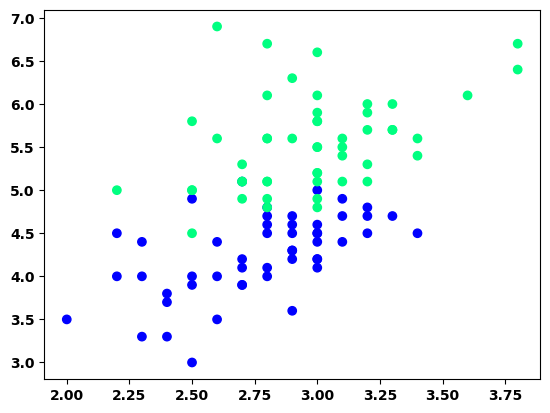

In [12]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')


In [13]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_train

,SepalWidthCm,PetalLengthCm,Species
104,3.0,5.8,2
107,2.9,6.3,2
84,3.0,4.5,1
80,2.4,3.8,1
103,2.9,5.6,2
96,2.9,4.2,1
120,3.2,5.7,2
129,3.0,5.8,2
85,3.4,4.5,1
128,2.8,5.6,2


In [15]:

X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# Case 1 - Bagging

In [16]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
120,3.2,5.7,2
85,3.4,4.5,1
128,2.8,5.6,2
96,2.9,4.2,1
80,2.4,3.8,1
80,2.4,3.8,1
128,2.8,5.6,2
128,2.8,5.6,2


In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [21]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [22]:
dt_bag1 = DecisionTreeClassifier()

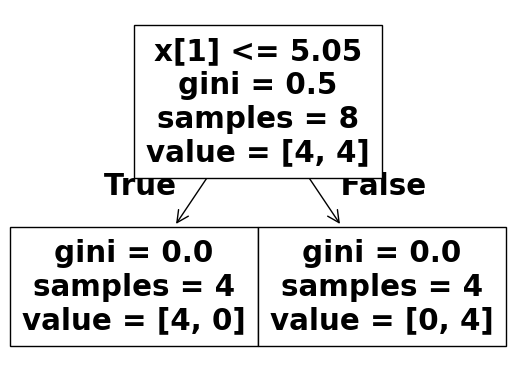

c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


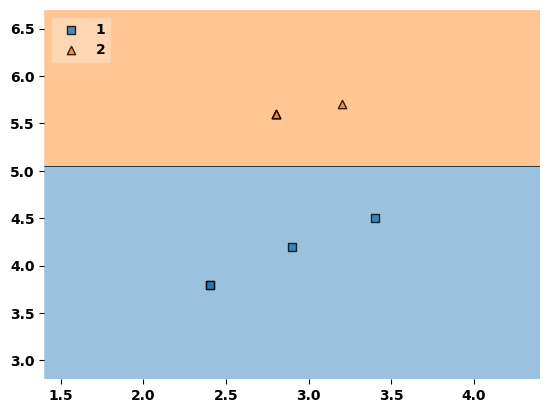

In [23]:

evaluate(dt_bag1,X,y)

In [24]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
80,2.4,3.8,1
107,2.9,6.3,2
103,2.9,5.6,2
96,2.9,4.2,1
107,2.9,6.3,2
129,3.0,5.8,2
129,3.0,5.8,2
80,2.4,3.8,1


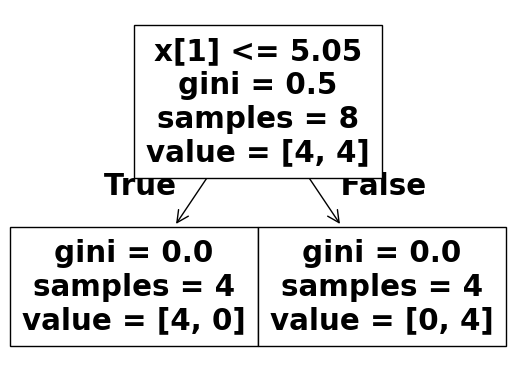

c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


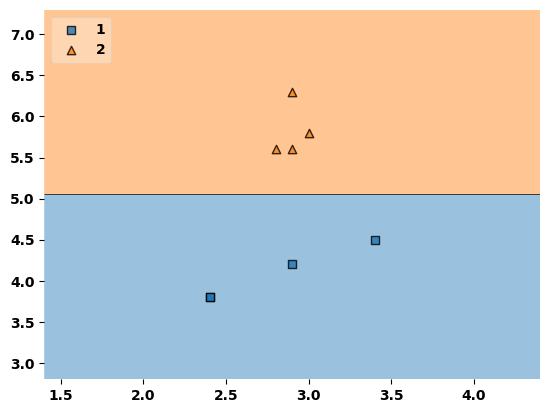

In [26]:

dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [27]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
104,3.0,5.8,2
107,2.9,6.3,2
96,2.9,4.2,1
129,3.0,5.8,2
120,3.2,5.7,2
129,3.0,5.8,2
129,3.0,5.8,2
84,3.0,4.5,1


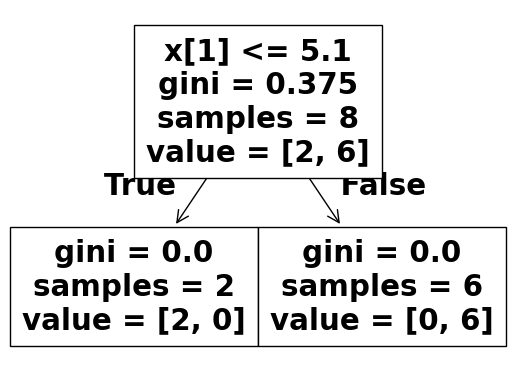

c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


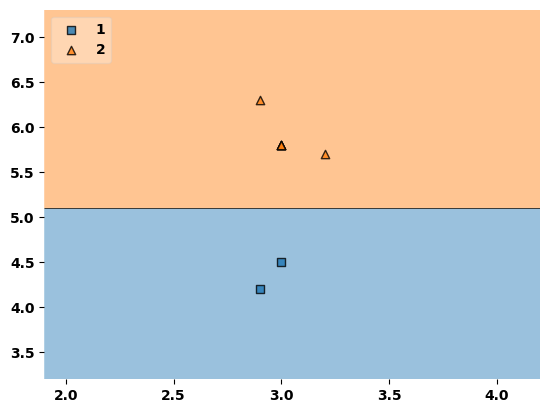

In [28]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [29]:
df_test

,SepalWidthCm,PetalLengthCm,Species
61,3.0,4.2,1
115,3.2,5.3,2
60,2.0,3.5,1
90,2.6,4.4,1
51,3.2,4.5,1


In [32]:

print("Predictor 1",dt_bag1.predict(np.array([3.2,5.3]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.2,5.3]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.2,5.3]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\anaconda3\envs\campusx_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [33]:

# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
104,3.0,5.8,2
107,2.9,6.3,2
84,3.0,4.5,1
80,2.4,3.8,1
103,2.9,5.6,2
96,2.9,4.2,1
120,3.2,5.7,2
129,3.0,5.8,2
85,3.4,4.5,1
128,2.8,5.6,2


# Random Subspaces

In [35]:
df1 = pd.read_csv("Iris.csv")
df1 = df1.sample(10)

In [36]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
85,86,6.0,3.4,4.5,1.6,Iris-versicolor
100,101,6.3,3.3,6.0,2.5,Iris-virginica
26,27,5.0,3.4,1.6,0.4,Iris-setosa
130,131,7.4,2.8,6.1,1.9,Iris-virginica
42,43,4.4,3.2,1.3,0.2,Iris-setosa
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
125,126,7.2,3.2,6.0,1.8,Iris-virginica
57,58,4.9,2.4,3.3,1.0,Iris-versicolor
21,22,5.1,3.7,1.5,0.4,Iris-setosa
81,82,5.5,2.4,3.7,1.0,Iris-versicolor


In [40]:

df1.sample(2,replace=True,axis=1)

,Id,SepalLengthCm
85,86,6.0
100,101,6.3
26,27,5.0
130,131,7.4
42,43,4.4
97,98,6.2
125,126,7.2
57,58,4.9
21,22,5.1
81,82,5.5


# Random Patches

In [45]:

df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,Species
125,6.0,Iris-virginica
26,1.6,Iris-setosa
21,1.5,Iris-setosa
42,1.3,Iris-setosa
125,6.0,Iris-virginica
81,3.7,Iris-versicolor
97,4.3,Iris-versicolor
42,1.3,Iris-setosa
